# 05 Q5 Behavior Semantics


In [1]:
import importlib
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import real_final_viz_helpers as viz
importlib.reload(viz)

apply_style    = viz.apply_style
load_csv       = viz.load_csv
annotate_demo  = viz.annotate_demo
clean_axes     = viz.clean_axes
dataset_label  = viz.dataset_label
metric_limits  = viz.metric_limits
panel_label    = viz.panel_label
PALETTE        = viz.PALETTE
DATASET_LABELS = viz.DATASET_LABELS
apply_style()

# ── Load data ─────────────────────────────────────────────────────────────────
case_df       = load_csv('q5_case_heatmap.csv')
interventions = load_csv('q5_intervention_summary.csv')

# ── Intervention delta prep ───────────────────────────────────────────────────
_metric_col = 'test_seen_mrr20' if 'test_seen_mrr20' in interventions.columns else 'test_mrr20'
base_df = (
    interventions[interventions['intervention_label'] == 'Full']
    [['dataset', _metric_col]]
    .rename(columns={_metric_col: 'base'})
)
delta_df = interventions.merge(base_df, on='dataset')
delta_df['delta'] = delta_df[_metric_col] - delta_df['base']
delta_df = delta_df[delta_df['intervention_label'] != 'Full'].copy()
delta_df['dataset_label'] = delta_df['dataset'].map(dataset_label)

# ── Case heatmap pivot helper ─────────────────────────────────────────────────
FAMILY_ORDER = ['memory', 'focus', 'tempo', 'exposure']
STAGE_ORDER = ['macro', 'mid', 'micro']
EXPERT_ORDER = ['expert_1', 'expert_2', 'expert_3']

def _ranked_stage_sums(values):
    """Map per-stage mass to rank bins: high/mid/low totals."""
    vals = [float(v) for v in values if pd.notna(v)]
    if not vals:
        return [0.0, 0.0, 0.0]
    vals = sorted(vals)  # ascending
    if len(vals) == 1:
        return [vals[0], vals[0], vals[0]]
    if len(vals) == 2:
        return [vals[1], 0.5 * (vals[0] + vals[1]), vals[0]]
    return [vals[-1], vals[-2], vals[-3]]

def make_case_pivot(dataset, case_name):
    """Return pivot: rows=expert_1/2/3, cols=group_name."""
    sub = case_df[(case_df['dataset'] == dataset) & (case_df['case_name'] == case_name)].copy()
    if sub.empty:
        return pd.DataFrame(0.0, index=EXPERT_ORDER, columns=FAMILY_ORDER)

    sub['expert_rank_or_slot'] = sub['expert_rank_or_slot'].astype(str)

    # Preferred path: real intra-group expert slots already exist in export.
    real = sub[sub['expert_rank_or_slot'].str.lower() != 'group_total']
    if not real.empty:
        pivot = (
            real.groupby(['expert_rank_or_slot', 'group_name'], as_index=False)['selected_mass']
            .mean()
            .pivot(index='expert_rank_or_slot', columns='group_name', values='selected_mass')
            .fillna(0.0)
        )
        for f in FAMILY_ORDER:
            if f not in pivot.columns:
                pivot[f] = 0.0
        return pivot[[c for c in FAMILY_ORDER if c in pivot.columns]]

    # Fallback path for group_total-only data:
    # for each group, sort stage masses and assign high/mid/low to expert_1/2/3.
    stage_group = (
        sub.groupby(['stage', 'group_name'], as_index=False)['selected_mass']
        .mean()
    )
    stage_group['stage'] = pd.Categorical(stage_group['stage'], categories=STAGE_ORDER, ordered=True)

    columns = {}
    for family in FAMILY_ORDER:
        vals = (
            stage_group[stage_group['group_name'] == family]
            .sort_values('stage')['selected_mass']
            .tolist()
        )
        hi_mid_low = _ranked_stage_sums(vals)
        columns[family] = hi_mid_low

    pivot = pd.DataFrame(columns, index=EXPERT_ORDER)
    return pivot[[c for c in FAMILY_ORDER if c in pivot.columns]]

available_ds = case_df['dataset'].unique()
CASE_DATASET = 'KuaiRecLargeStrictPosV2_0.2' if 'KuaiRecLargeStrictPosV2_0.2' in available_ds else available_ds[0]
CASE_DS_LABEL = DATASET_LABELS.get(CASE_DATASET, CASE_DATASET)

repeat_case = make_case_pivot(CASE_DATASET, 'Repeat-heavy')
fast_case = make_case_pivot(CASE_DATASET, 'Fast exploratory')
focus_case = make_case_pivot(CASE_DATASET, 'Narrow-focus')

all_vals = list(repeat_case.values.flatten()) + list(fast_case.values.flatten()) + list(focus_case.values.flatten())
_heat_vmax = max(max(all_vals) + 0.04, 0.52) if all_vals else 0.52
print(f"CASE_DATASET={CASE_DATASET}, _heat_vmax={_heat_vmax:.3f}")
print(f"Heatmap shape: {repeat_case.shape}  rows={list(repeat_case.index)}  cols={list(repeat_case.columns)}")

CASE_DATASET=KuaiRecLargeStrictPosV2_0.2, _heat_vmax=0.520
Heatmap shape: (3, 4)  rows=['expert_1', 'expert_2', 'expert_3']  cols=['memory', 'focus', 'tempo', 'exposure']


[saved] a05_routing_profiles_a.pdf  -> /workspace/FeaturedMoE/writing/ACM_template/figures/appendix


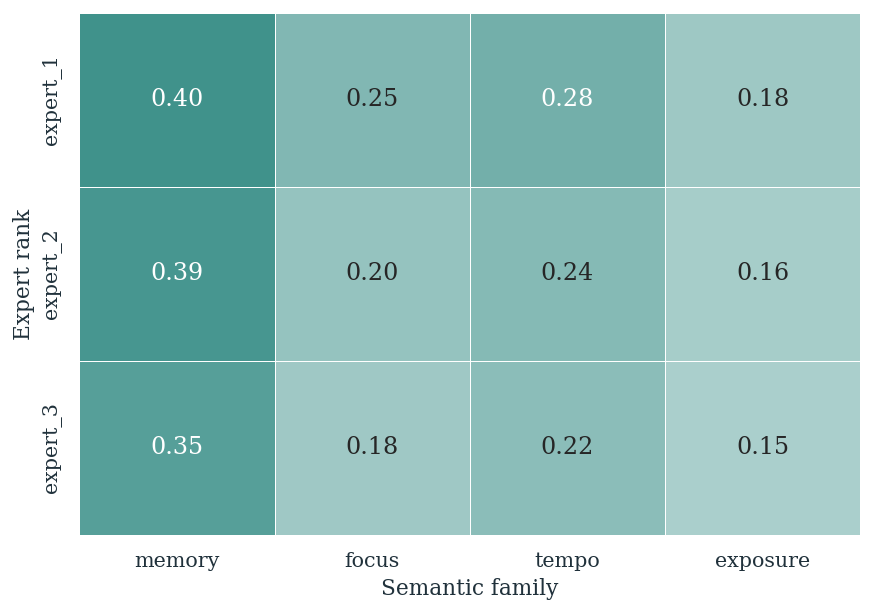

In [ ]:
# (a) Repeat-heavy — stage-ranked expert allocation (high/mid/low)
fig, ax = plt.subplots(1, 1, figsize=(5.8, 4.0), constrained_layout=True)
sns.heatmap(
    repeat_case,
    cmap=sns.light_palette(PALETTE['route'], as_cmap=True),
    vmin=0.0, vmax=_heat_vmax,
    annot=True, fmt='.2f', cbar=False,
    annot_kws={'size': 15.0},
    linewidths=0.46, linecolor='white',
    ax=ax,
 )
ax.set_xlabel('Semantic family', fontsize=12.6)
ax.set_ylabel('Expert rank', fontsize=12.6)
ax.set_title('')
ax.tick_params(axis='x', rotation=0, labelsize=12.0)
ax.tick_params(axis='y', labelsize=12.0)
_fig_dir = (Path(__file__).resolve().parents[2] / 'ACM_template' / 'figures' / 'appendix') if '__file__' in dir() else (Path('..') / 'ACM_template' / 'figures' / 'appendix').resolve()
_fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_fig_dir / 'a05_routing_profiles_a.pdf', bbox_inches='tight')
print(f'[saved] a05_routing_profiles_a.pdf  -> {_fig_dir}')
plt.show()


[saved] a05_routing_profiles_b.pdf  -> /workspace/FeaturedMoE/writing/ACM_template/figures/appendix


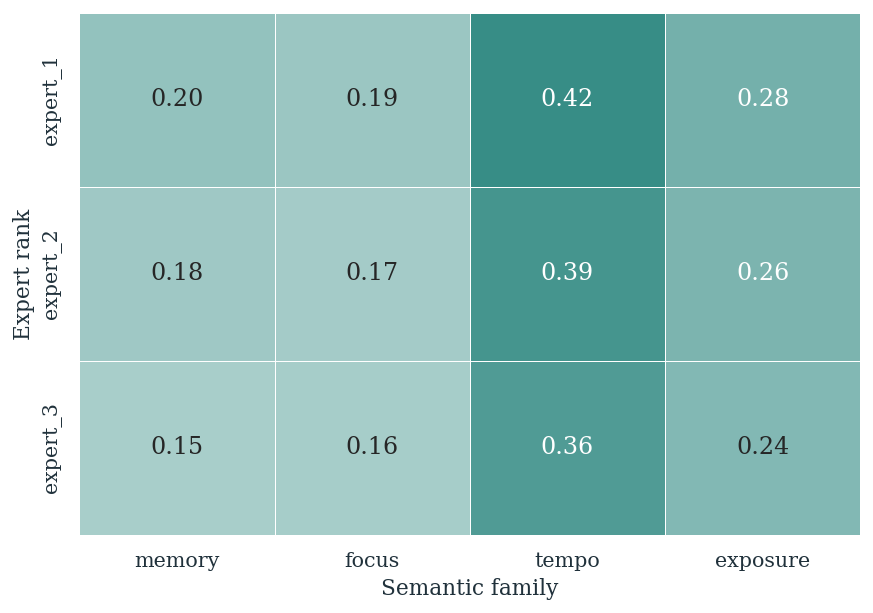

In [ ]:
# (b) Fast exploratory — stage-ranked expert allocation (high/mid/low)
fig, ax = plt.subplots(1, 1, figsize=(5.8, 4.0), constrained_layout=True)
sns.heatmap(
    fast_case,
    cmap=sns.light_palette(PALETTE['route'], as_cmap=True),
    vmin=0.0, vmax=_heat_vmax,
    annot=True, fmt='.2f', cbar=False,
    annot_kws={'size': 15.0},
    linewidths=0.46, linecolor='white',
    ax=ax,
 )
ax.set_xlabel('Semantic family', fontsize=12.6)
ax.set_ylabel('Expert rank', fontsize=12.6)
ax.set_title('')
ax.tick_params(axis='x', rotation=0, labelsize=12.0)
ax.tick_params(axis='y', labelsize=12.0)
_fig_dir = (Path(__file__).resolve().parents[2] / 'ACM_template' / 'figures' / 'appendix') if '__file__' in dir() else (Path('..') / 'ACM_template' / 'figures' / 'appendix').resolve()
_fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_fig_dir / 'a05_routing_profiles_b.pdf', bbox_inches='tight')
print(f'[saved] a05_routing_profiles_b.pdf  -> {_fig_dir}')
plt.show()


[saved] a05_routing_profiles_c.pdf  -> /workspace/FeaturedMoE/writing/ACM_template/figures/appendix


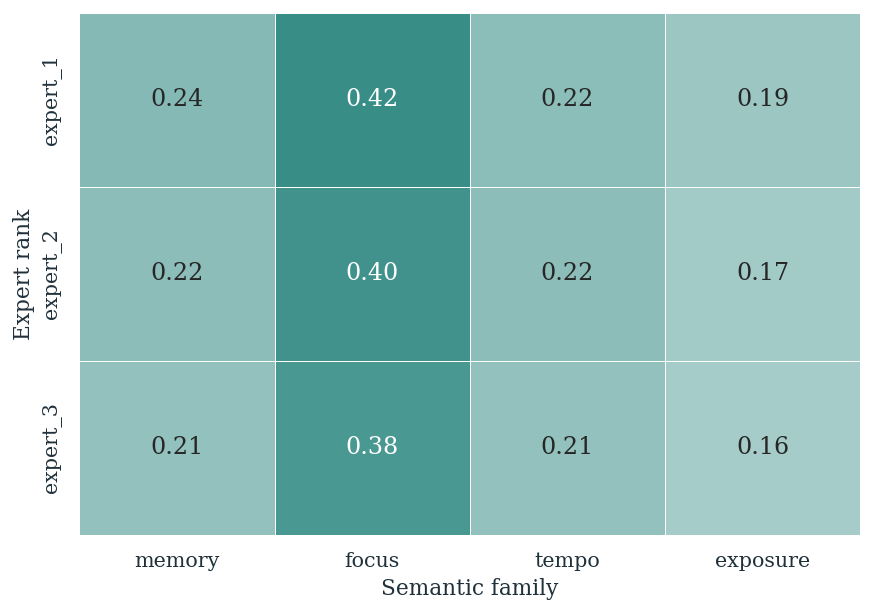

In [ ]:
# (c) Narrow-focus — stage-ranked expert allocation (high/mid/low)
fig, ax = plt.subplots(1, 1, figsize=(5.8, 4.0), constrained_layout=True)
sns.heatmap(
    focus_case,
    cmap=sns.light_palette(PALETTE['route'], as_cmap=True),
    vmin=0.0, vmax=_heat_vmax,
    annot=True, fmt='.2f', cbar=False,
    annot_kws={'size': 15.0},
    linewidths=0.46, linecolor='white',
    ax=ax,
 )
ax.set_xlabel('Semantic family', fontsize=12.6)
ax.set_ylabel('Expert rank', fontsize=12.6)
ax.set_title('')
ax.tick_params(axis='x', rotation=0, labelsize=12.0)
ax.tick_params(axis='y', labelsize=12.0)
_fig_dir = (Path(__file__).resolve().parents[2] / 'ACM_template' / 'figures' / 'appendix') if '__file__' in dir() else (Path('..') / 'ACM_template' / 'figures' / 'appendix').resolve()
_fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_fig_dir / 'a05_routing_profiles_c.pdf', bbox_inches='tight')
print(f'[saved] a05_routing_profiles_c.pdf  -> {_fig_dir}')
plt.show()


[saved] a05_routing_profiles.pdf  -> /workspace/FeaturedMoE/writing/ACM_template/figures/appendix


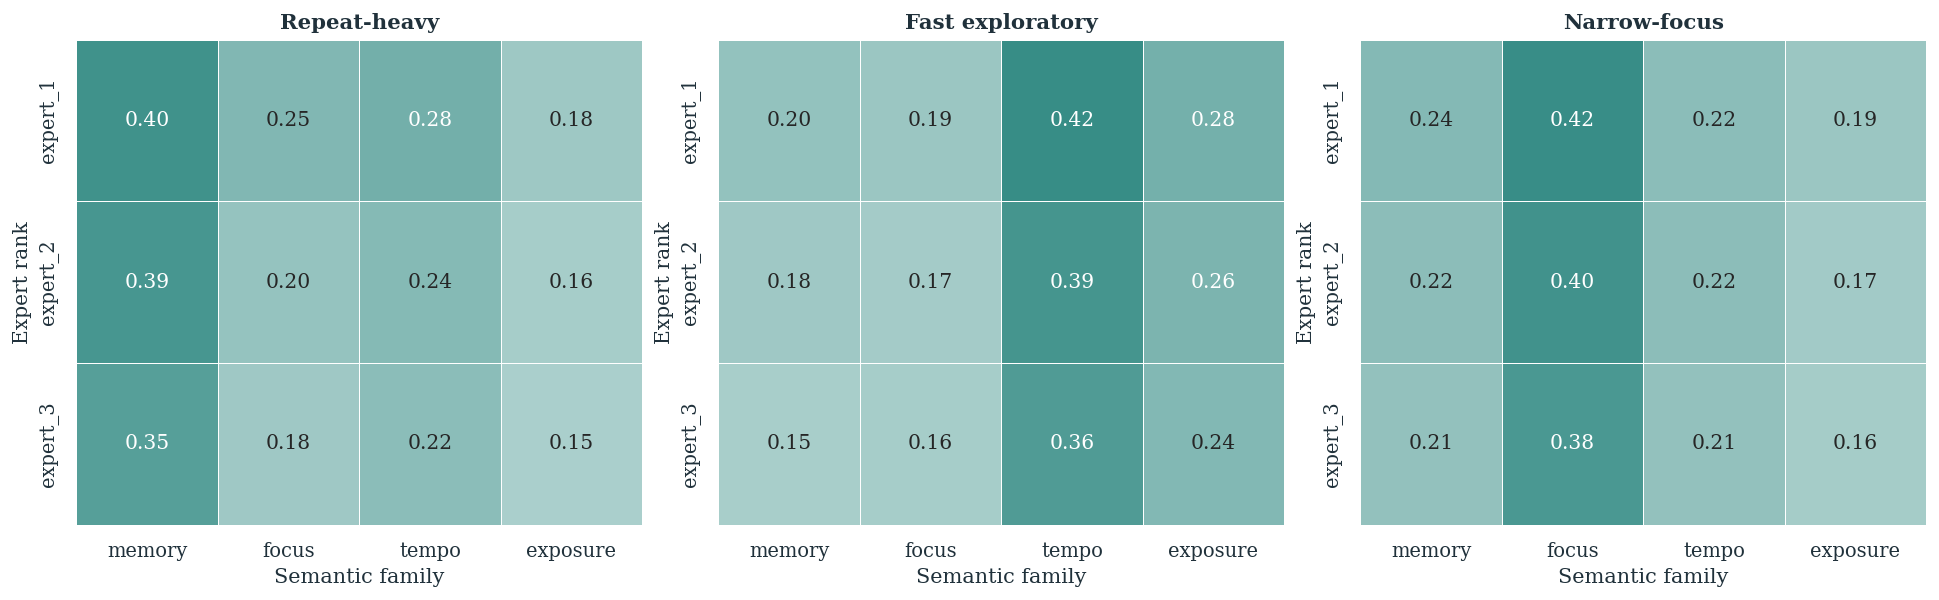

In [9]:
# Combined 3-case panel for appendix compatibility.
fig, axes = plt.subplots(1, 3, figsize=(14.8, 4.5), constrained_layout=True)
for ax, panel, title in [
    (axes[0], repeat_case, 'Repeat-heavy'),
    (axes[1], fast_case, 'Fast exploratory'),
    (axes[2], focus_case, 'Narrow-focus'),
]:
    sns.heatmap(
        panel,
        cmap=sns.light_palette(PALETTE['route'], as_cmap=True),
        vmin=0.0, vmax=_heat_vmax,
        annot=True, fmt='.2f', cbar=False,
        annot_kws={'size': 11.2},
        linewidths=0.42, linecolor='white',
        ax=ax,
    )
    ax.set_xlabel('Semantic family', fontsize=11.5)
    ax.set_ylabel('Expert rank', fontsize=11.2)
    ax.set_title(title, fontsize=11.8)
    ax.tick_params(axis='x', rotation=0, labelsize=10.8)
    ax.tick_params(axis='y', labelsize=10.8)

_fig_dir = (Path(__file__).resolve().parents[2] / 'ACM_template' / 'figures' / 'appendix') if '__file__' in dir() else (Path('..') / 'ACM_template' / 'figures' / 'appendix').resolve()
_fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_fig_dir / 'a05_routing_profiles.pdf', bbox_inches='tight')
print(f'[saved] a05_routing_profiles.pdf  -> {_fig_dir}')
plt.show()


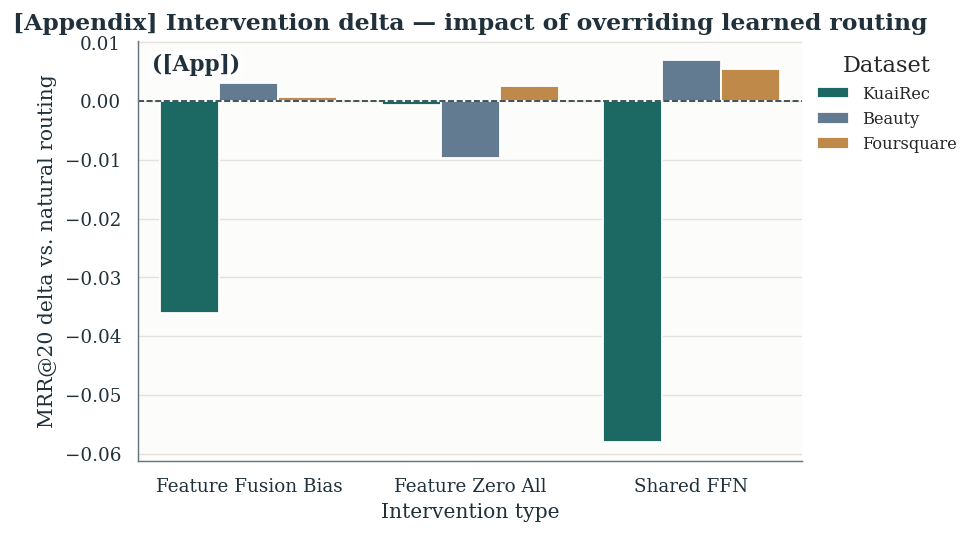

In [6]:
# ── [→ Appendix] Intervention delta: performance change under forced routing ──
# Shows that the router's natural choices are near-optimal vs. forced alternatives.
if delta_df is not None and len(delta_df) > 0:
    apply_style()
    datasets_disp = sorted(delta_df['dataset_label'].unique())
    pal_colors = [PALETTE['blue'], PALETTE['orange'], PALETTE['route'], PALETTE['rose']]
    palette_ds = {d: pal_colors[i % len(pal_colors)] for i, d in enumerate(datasets_disp)}

    fig, ax = plt.subplots(1, 1, figsize=(7.2, 4.0), constrained_layout=True)
    sns.barplot(
        data=delta_df,
        x='intervention_label', y='delta',
        hue='dataset_label',
        palette=palette_ds,
        ax=ax,
        order=sorted(delta_df['intervention_label'].unique()),
    )
    ax.axhline(0, color=PALETTE['ink'], linewidth=0.9, linestyle='--')
    ax.set_xlabel('Intervention type')
    ax.set_ylabel('MRR@20 delta vs. natural routing')
    ax.set_title('[Appendix] Intervention delta — impact of overriding learned routing')
    ax.legend(title='Dataset', bbox_to_anchor=(1.0, 1.0), loc='upper left', fontsize=9)
    panel_label(ax, '[App]')
    clean_axes(ax)
    plt.show()
else:
    print("delta_df is empty — fill q5_intervention_summary.csv to generate this figure.")
